# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [3]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [4]:
data.counterfeit.value_counts()

counterfeit
0    609
1    488
Name: count, dtype: int64

In [5]:
X = data[["a1", "a2", "a3"]]
y = data["counterfeit"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Problem 

### A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve. 

[[144  39]
 [ 24 123]]
AUC: 0.880710754247054


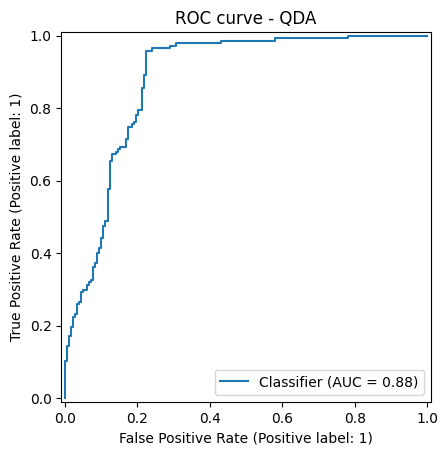

In [6]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)
qda_proba = qda.predict_proba(X_test)[:, 1]

cm_qda = confusion_matrix(y_test, qda_pred)
auc_qda = roc_auc_score(y_test, qda_proba)

print(cm_qda)
print("AUC:", auc_qda)

RocCurveDisplay.from_predictions(y_test, qda_proba)
plt.title("ROC curve - QDA")
plt.show()

### B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve. 

Pierwsze 10 prawdopodobieństw:
[0.99136563 0.33320345 0.99996687 0.27309663 0.00791277 0.21579061
 0.99986916 0.92510807 0.99478029 0.08687861]
Confusion matrix for MGDA:
[[174   9]
 [ 23 124]]
AUC dla MGDA: 0.9654659678078882


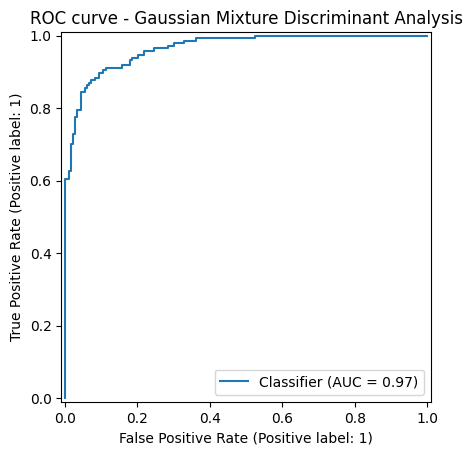

In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
import numpy as np
import matplotlib.pyplot as plt

X0_train = X_train[y_train == 0]
X1_train = X_train[y_train == 1]

gm0 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gm1 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gm0.fit(X0_train)
gm1.fit(X1_train)


def make_predict_proba(gm0, gm1, pi1=0.445):
    
    pi0 = 1 - pi1

    def predict_proba(X):
        log_density0 = gm0.score_samples(X)
        log_density1 = gm1.score_samples(X)

        log_p0 = np.log(pi0) + log_density0
        log_p1 = np.log(pi1) + log_density1

        max_log = np.maximum(log_p0, log_p1)

        p0 = np.exp(log_p0 - max_log)
        p1 = np.exp(log_p1 - max_log)

        proba_class_1 = p1 / (p0 + p1)

        return proba_class_1

    return predict_proba


# Probability prediction
mgda = make_predict_proba(gm0, gm1, pi1=0.445)

mgda_test_proba = mgda(X_test)

print("Pierwsze 10 prawdopodobieństw:")
print(mgda_test_proba[:10])


# Class prediction
mgda_test_pred = (mgda_test_proba >= 0.5).astype(int)


# Confusion matrix
cm_mgda = confusion_matrix(y_test, mgda_test_pred)

print("Confusion matrix for MGDA:")
print(cm_mgda)


# AUC
auc_mgda = roc_auc_score(y_test, mgda_test_proba)

print("AUC dla MGDA:", auc_mgda)


# ROC
RocCurveDisplay.from_predictions(y_test, mgda_test_proba)

plt.title("ROC curve - Gaussian Mixture Discriminant Analysis")
plt.show()

mgda = make_predict_proba(gm0, gm1,pi1=0.445)

In [8]:
mgda_test_proba[:10]

array([0.99136563, 0.33320345, 0.99996687, 0.27309663, 0.00791277,
       0.21579061, 0.99986916, 0.92510807, 0.99478029, 0.08687861])